# Maize — Baseline Model Benchmarking: Aggregated Summary Table and Significance Testing

**Purpose:** Loads the per-run `_metrics_summary.csv` files produced by `maizeMLModels_eval_set.ipynb` across all five GROUP configurations, assembles them into a single comparison table, displays it in-notebook, exports a formatted Excel file and flat CSV, and produces a 3×2 significance-annotated bar chart comparing model architectures within each group.

**Five configurations:** All, Group I, Group II, Group III, Group IV.

**Models evaluated:** Logistic Regression (LR), Support Vector Machine (SVM), Random Forest (RF), XGBoost (XGB) — all with default hyperparameters, evaluated by stratified 10-fold cross-validation on NaN-dropped datasets.

**Positive class:** WGD=1 (Maize2, submissive subgenome). Precision, Recall, and F1 are reported with respect to this class.

**To use:** Set `MAIZE_EVAL_DIR` and `OUTPUT_DIR` in the configuration cell, then run all cells.

In [1]:
# ============================================================
# CONFIGURATION
# MAIZE_EVAL_DIR : directory containing all per-run
#                  _metrics_summary.csv and _fold_f1.csv files
#                  produced by maizeMLModels_eval_set.ipynb.
# OUTPUT_DIR     : where the final Excel, CSV, and figure
#                  are saved. Can be the same as MAIZE_EVAL_DIR.
# ============================================================

MAIZE_EVAL_DIR = (
    "/blue/meixiazhao/laylaaschuster/maizeGDM/final_models/eval_set"
)

OUTPUT_DIR = MAIZE_EVAL_DIR

# --- Output file names ---
OUTPUT_EXCEL  = f"{OUTPUT_DIR}/maize_benchmarking_summary.xlsx"
OUTPUT_CSV    = f"{OUTPUT_DIR}/maize_benchmarking_summary.csv"
FIG_SIG_PATH  = f"{OUTPUT_DIR}/maize_benchmarking_significance.png"

# --- Run configurations ---
# Each tuple: (GROUP_PREFIX used in the eval notebook, display label for the table).
# The GROUP_PREFIX determines CSV filenames: {prefix}_metrics_summary.csv
#                                        and {prefix}_{abbrev}_fold_f1.csv
# Order here defines the row order in the final summary table.
RUN_CONFIGS = [
    ("eval_groupAll",  "All"),
    ("eval_groupI",    "Group I"),
    ("eval_groupII",   "Group II"),
    ("eval_groupIII",  "Group III"),
    ("eval_groupIV",   "Group IV"),
]

# --- Model abbreviation (CSV 'abbrev' column) -> display name in table ---
MODEL_DISPLAY = {
    "logreg": "LR",
    "svm":    "SVM",
    "rf":     "RF",
    "xgb":    "XGB",
}

# --- Model row order within each comparison group ---
# Must match the abbreviation keys in MODEL_DISPLAY above.
MODEL_ORDER = ["logreg", "svm", "rf", "xgb"]


In [2]:
# ============================================================
# IMPORTS
# ============================================================

import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display
from openpyxl import Workbook
from openpyxl.styles import Alignment, Border, Font, PatternFill, Side
from openpyxl.utils import get_column_letter
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests


In [3]:
# ============================================================
# LOAD AND ASSEMBLE METRICS FROM ALL RUN CSVs
#
# Each _metrics_summary.csv has one row per model (4 rows).
# We load all 5, enforce MODEL_ORDER within each, and
# stack into one summary_table (20 rows total).
#
# Columns pulled from each CSV:
#   abbrev           : model abbreviation key
#   f1_mean, f1_std  : mean and std of per-fold F1 (10 folds)
#   f1_pooled        : F1 on all predictions concatenated across folds
#   precision_pooled : pooled precision (positive class = Maize2, WGD=1)
#   recall_pooled    : pooled recall
#   accuracy_pooled  : pooled accuracy
#   auc_pooled       : ROC AUC on pooled predictions
# ============================================================

all_rows = []

for prefix, display_label in RUN_CONFIGS:

    csv_path = os.path.join(MAIZE_EVAL_DIR, f"{prefix}_metrics_summary.csv")

    # Explicit check: fails loudly if a run CSV is missing
    assert os.path.exists(csv_path), (
        f"Missing expected CSV: {csv_path}\n"
        f"Check that MAIZE_EVAL_DIR is correct and all 5 runs are complete."
    )

    df = pd.read_csv(csv_path)

    # Enforce the display order of models within each comparison group
    df = df.set_index("abbrev").loc[MODEL_ORDER].reset_index()

    for _, row in df.iterrows():
        all_rows.append({
            "Model Comparison": display_label,
            "Model*":           MODEL_DISPLAY[row["abbrev"]],
            "F1 Mean ± Std":    f"{row['f1_mean']:.4f} ± {row['f1_std']:.4f}",
            "F1 Pooled":        round(row["f1_pooled"],        4),
            "Precision Pooled": round(row["precision_pooled"], 4),
            "Recall Pooled":    round(row["recall_pooled"],    4),
            "Accuracy Pooled":  round(row["accuracy_pooled"],  4),
            "AUC Pooled":       round(row["auc_pooled"],       4),
        })

summary_table = pd.DataFrame(all_rows)

print(f"Assembled: {len(summary_table)} rows x {len(summary_table.columns)} columns")
print(f"Groups   : {summary_table['Model Comparison'].unique().tolist()}")


Assembled: 20 rows x 8 columns
Groups   : ['All', 'Group I', 'Group II', 'Group III', 'Group IV']


In [4]:
# ============================================================
# DISPLAY TABLE IN NOTEBOOK
#
# "Model Comparison" label shown only on the first model row
# within each group, mirroring the merged-cell layout used
# in the exported Excel file.
# ============================================================

display_df = summary_table.copy()

# Suppress repeated "Model Comparison" labels within each group
is_first = display_df["Model Comparison"] != display_df["Model Comparison"].shift()
display_df.loc[~is_first, "Model Comparison"] = ""

# Style: header in dark blue/white; bold Model Comparison column
styled = (
    display_df.reset_index(drop=True)
    .style
    .set_properties(
        subset=["Model Comparison"],
        **{"font-weight": "bold"}
    )
    .set_table_styles([{
        "selector": "th",
        "props": [
            ("background-color", "#2F5597"),
            ("color",            "white"),
            ("font-weight",      "bold"),
            ("text-align",       "center"),
        ]
    }])
    .hide(axis="index")
)

display(styled)


Model Comparison,Model*,F1 Mean ± Std,F1 Pooled,Precision Pooled,Recall Pooled,Accuracy Pooled,AUC Pooled
All,LR,0.5482 ± 0.0249,0.548500,0.543800,0.553300,0.545200,0.570400
,SVM,0.5251 ± 0.0189,0.525300,0.549800,0.502900,0.546200,0.564900
,RF,0.5895 ± 0.0161,0.589400,0.611300,0.569100,0.604100,0.639000
,XGB,0.6060 ± 0.0152,0.606000,0.614600,0.597700,0.612000,0.656900
Group I,LR,0.5384 ± 0.0198,0.538600,0.547300,0.530200,0.546400,0.576300
,SVM,0.5375 ± 0.0243,0.537500,0.569500,0.509000,0.562700,0.590000
,RF,0.6311 ± 0.0147,0.631100,0.691000,0.580700,0.661000,0.694400
,XGB,0.6433 ± 0.0205,0.643500,0.668900,0.619900,0.657000,0.706400
Group II,LR,0.5301 ± 0.0435,0.531000,0.514400,0.548700,0.514600,0.502200
,SVM,0.3353 ± 0.1713,0.370600,0.462500,0.309200,0.474200,0.467100


In [5]:
# ============================================================
# EXPORT: FORMATTED EXCEL AND FLAT CSV
#
# Excel layout:
#   Row 1    : header row — dark blue (#2F5597) background,
#              white bold Arial text
#   Rows 2+  : data rows — alternating light blue (#D9E8F5) /
#              white (#FFFFFF) background by comparison group
#   Column A : "Model Comparison" cells merged vertically
#              across the 4 model rows per group; centered, bold
#   All cells: thin border, Arial 10pt
#   Row 1    : frozen for scrolling
# ============================================================

# --- Style constants ---

HEADER_FILL = PatternFill("solid", fgColor="2F5597")    # dark blue
HEADER_FONT = Font(bold=True, color="FFFFFF", name="Arial", size=10)

# Odd-indexed groups (0, 2, 4) = light blue; even (1, 3) = white
GROUP_FILLS = [
    PatternFill("solid", fgColor="D9E8F5"),   # light blue
    PatternFill("solid", fgColor="FFFFFF"),   # white
]

DATA_FONT    = Font(name="Arial", size=10)
BOLD_FONT    = Font(name="Arial", size=10, bold=True)
CENTER_ALIGN = Alignment(horizontal="center", vertical="center", wrap_text=True)
THIN_SIDE    = Side(style="thin")
THIN_BORDER  = Border(
    left=THIN_SIDE, right=THIN_SIDE,
    top=THIN_SIDE,  bottom=THIN_SIDE,
)

# Column display names paired with column widths (characters)
COLUMNS = [
    ("Model Comparison", 22),
    ("Model*",            9),
    ("F1 Mean ± Std",    21),
    ("F1 Pooled",         13),
    ("Precision Pooled",  17),
    ("Recall Pooled",     15),
    ("Accuracy Pooled",   17),
    ("AUC Pooled",        13),
]
COL_NAMES = [c[0] for c in COLUMNS]

# --- Build workbook ---
wb = Workbook()
ws = wb.active
ws.title = "Benchmarking Summary"

# Header row
for col_idx, (col_name, _) in enumerate(COLUMNS, start=1):
    cell           = ws.cell(row=1, column=col_idx, value=col_name)
    cell.font      = HEADER_FONT
    cell.fill      = HEADER_FILL
    cell.alignment = CENTER_ALIGN
    cell.border    = THIN_BORDER

ws.row_dimensions[1].height = 28   # slightly taller header

# Data rows
n_models = len(MODEL_ORDER)   # 4 models per comparison group

for group_idx, (prefix, display_label) in enumerate(RUN_CONFIGS):

    group_fill      = GROUP_FILLS[group_idx % 2]
    start_excel_row = 2 + group_idx * n_models
    end_excel_row   = start_excel_row + n_models - 1

    group_rows = (
        summary_table[summary_table["Model Comparison"] == display_label]
        .reset_index(drop=True)
    )

    for model_idx, (_, data_row) in enumerate(group_rows.iterrows()):
        excel_row = start_excel_row + model_idx

        for col_idx, (col_name, _) in enumerate(COLUMNS, start=1):

            cell        = ws.cell(row=excel_row, column=col_idx)
            cell.fill   = group_fill
            cell.border = THIN_BORDER

            if col_name == "Model Comparison":
                # Only write the label on the first row; the merge handles display
                cell.value     = display_label if model_idx == 0 else None
                cell.font      = BOLD_FONT
                cell.alignment = CENTER_ALIGN
            else:
                cell.value     = data_row[col_name]
                cell.font      = DATA_FONT
                cell.alignment = CENTER_ALIGN

    # Merge "Model Comparison" column (A) vertically across all 4 model rows
    ws.merge_cells(f"A{start_excel_row}:A{end_excel_row}")

    # openpyxl requires re-applying style to the merged cell object after merge
    merged_cell           = ws[f"A{start_excel_row}"]
    merged_cell.font      = BOLD_FONT
    merged_cell.fill      = group_fill
    merged_cell.alignment = CENTER_ALIGN
    merged_cell.border    = THIN_BORDER

# Set column widths
for col_idx, (_, width) in enumerate(COLUMNS, start=1):
    ws.column_dimensions[get_column_letter(col_idx)].width = width

# Freeze header row so it stays visible when scrolling
ws.freeze_panes = "A2"

# --- Save Excel ---
wb.save(OUTPUT_EXCEL)
print(f"Saved Excel : {OUTPUT_EXCEL}")

# --- Flat CSV (no merged cells; all 20 rows fully labeled) ---
summary_table.to_csv(OUTPUT_CSV, index=False)
print(f"Saved CSV   : {OUTPUT_CSV}")


Saved Excel : /blue/meixiazhao/laylaaschuster/maizeGDM/final_models/eval_set/maize_benchmarking_summary.xlsx
Saved CSV   : /blue/meixiazhao/laylaaschuster/maizeGDM/final_models/eval_set/maize_benchmarking_summary.csv


/blue/raquel.dias/laylaaschuster/conda/envs/maize_prom/lib/python3.11/site-packages/scipy/stats/_morestats.py:4088: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/blue/raquel.dias/laylaaschuster/conda/envs/maize_prom/lib/python3.11/site-packages/scipy/stats/_morestats.py:4102: UserWarning: Sample size too small for normal approximation.
  warnings.warn("Sample size too small for normal approximation.")


Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_models/eval_set/maize_benchmarking_significance.png


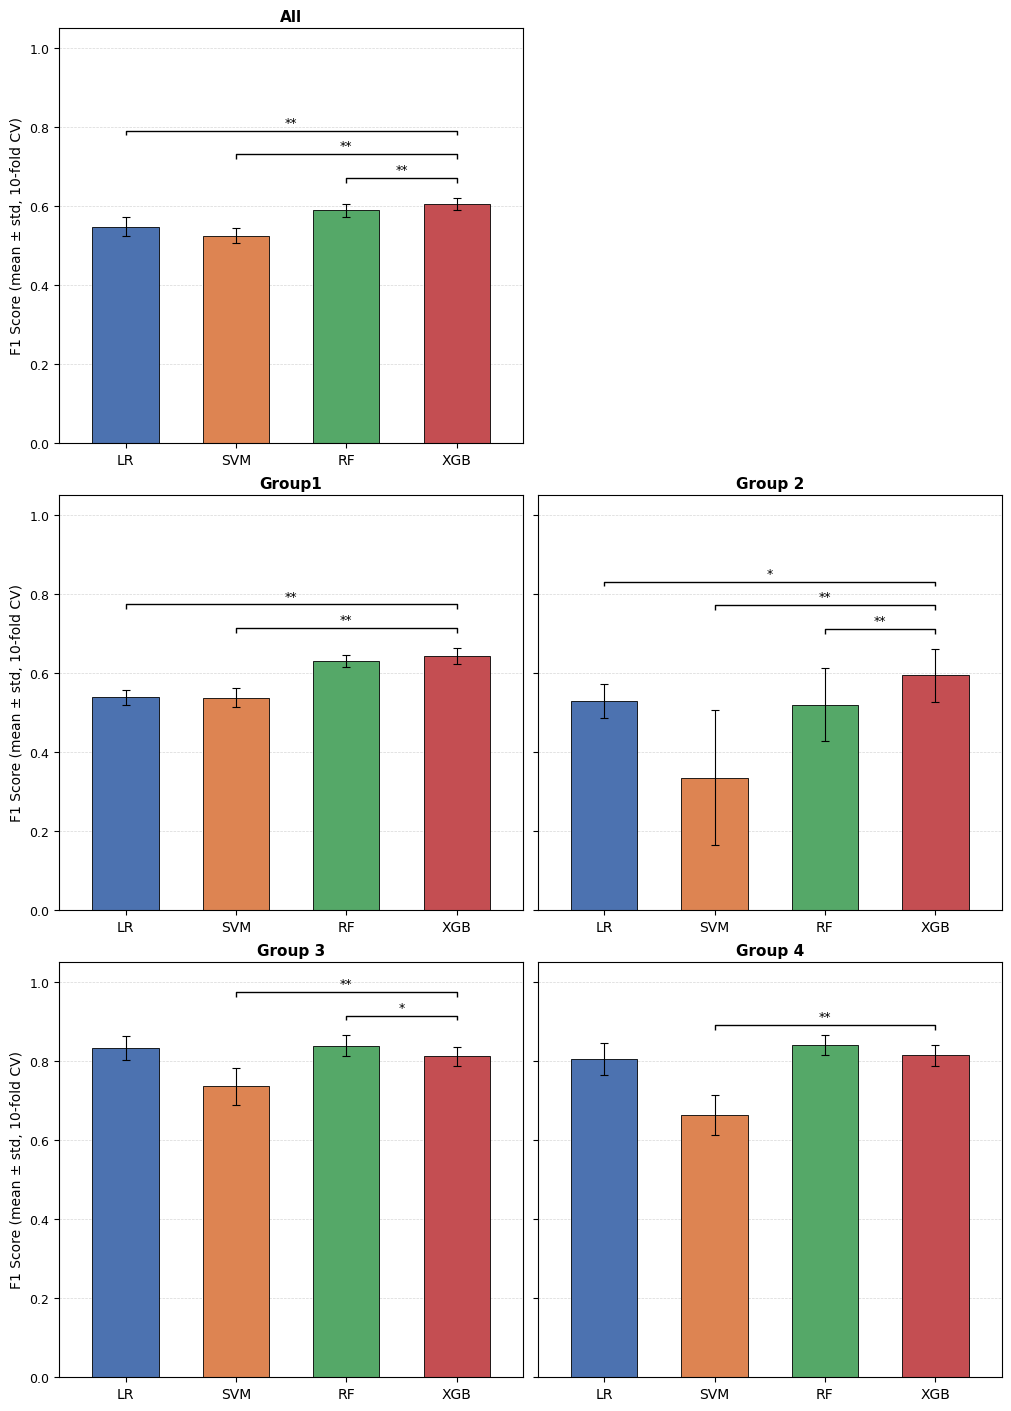

In [12]:
# ============================================================
# SIGNIFICANCE TESTING + BAR CHART
#
# For each of the 5 comparison groups: loads per-fold F1
# scores for all four architectures, runs three Wilcoxon
# signed-rank tests (LR vs XGB, SVM vs XGB, RF vs XGB),
# applies Benjamini-Hochberg FDR correction within each
# group independently, and draws significance brackets only
# for p_adj < SIG_ALPHA.
#
# Layout: 3 rows x 2 columns.
#   Row 0 : All (left),    empty panel (right)
#   Row 1 : Group I (left), Group II (right)
#   Row 2 : Group III (left), Group IV (right)
#
# Note: comparisons are made only between architectures
# trained on the same dataset. Cross-group comparisons
# are not tested and should not be inferred from the figure.
#
# Note: with n=10 folds, the minimum achievable Wilcoxon
# p-value is 1/2^10 ~ 0.001, so *** requires a perfectly
# one-directional difference across all 10 folds.
# ============================================================

# ============================================================
# TUNABLE PARAMETERS
# ============================================================

# Per-fold F1 files live in the same directory as the summary CSVs
FOLD_F1_DIR = MAIZE_EVAL_DIR

# Colors for each architecture (colorblind-contrasting)
MODEL_COLORS = {
    "logreg": "#4C72B0",   # muted blue
    "svm":    "#DD8452",   # muted orange
    "rf":     "#55A868",   # muted green
    "xgb":    "#C44E52",   # muted red
}

# Significance threshold applied to FDR-corrected p-values
SIG_ALPHA = 0.05

# Bar styling
BAR_WIDTH  = 0.6
EDGE_COLOR = "black"
EDGE_WIDTH = 0.6
ERROR_KW   = dict(ecolor="black", capsize=3, capthick=0.8, elinewidth=0.8)

# Bracket geometry (in data / axis fraction units)
BRACKET_GAP  = 0.05    # clearance above the tallest error bar before first bracket
BRACKET_STEP = 0.06    # vertical distance between stacked brackets
BRACKET_DROP = 0.012   # length of the vertical tick at each bracket end
BRACKET_LW   = 1.0     # bracket line width
BRACKET_FS   = 9       # significance symbol font size

# 3 x 2 grid layout.
# None marks the empty panel (top right).
# Each non-None entry: (GROUP_PREFIX, panel title)
GRID_LAYOUT = [
    [("eval_groupAll",  "All"),     None],
    [("eval_groupI",    "Group1"), ("eval_groupII",  "Group 2")],
    [("eval_groupIII",  "Group 3"), ("eval_groupIV", "Group 4")],
]

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def p_to_symbol(p):
    # Convert a p-value to a standard significance symbol.
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return "ns"


def draw_bracket(ax, x1, x2, y_base, symbol):
    # Draw a significance bracket between bar positions x1 and x2.
    # The horizontal bar sits at y_base; vertical drops extend
    # downward by BRACKET_DROP. The symbol is placed just above
    # the midpoint of the horizontal bar.
    ax.plot(
        [x1, x1, x2, x2],
        [y_base - BRACKET_DROP, y_base, y_base, y_base - BRACKET_DROP],
        lw=BRACKET_LW, color="black", solid_capstyle="butt",
        zorder=3,
    )
    ax.text(
        (x1 + x2) / 2, y_base + 0.004, symbol,
        ha="center", va="bottom",
        fontsize=BRACKET_FS, color="black", zorder=3,
    )


# ============================================================
# MAIN: LOAD DATA, TEST, PLOT
# ============================================================

fig, axes = plt.subplots(
    3, 2,
    figsize=(10, 14),
    sharey=True,
    constrained_layout=True,
)

x_positions = np.arange(len(MODEL_ORDER))   # [0, 1, 2, 3]
xgb_pos     = MODEL_ORDER.index("xgb")      # 3
baselines   = [m for m in MODEL_ORDER if m != "xgb"]   # [logreg, svm, rf]

for row_idx, row_configs in enumerate(GRID_LAYOUT):
    for col_idx, panel in enumerate(row_configs):

        ax = axes[row_idx, col_idx]

        # --- Empty panel: hide axes and skip ---
        if panel is None:
            ax.set_visible(False)
            continue

        prefix, title = panel

        # --- Load per-fold F1 scores for each architecture ---
        fold_f1 = {}   # abbrev -> np.array, shape (10,)
        means   = {}   # abbrev -> float
        stds    = {}   # abbrev -> float

        for abbrev in MODEL_ORDER:
            fpath = os.path.join(
                FOLD_F1_DIR, f"{prefix}_{abbrev}_fold_f1.csv"
            )
            assert os.path.exists(fpath), (
                f"Missing fold F1 file:\n  {fpath}\n"
                f"Check FOLD_F1_DIR and that all eval runs are complete."
            )
            scores          = pd.read_csv(fpath)["f1"].values
            fold_f1[abbrev] = scores
            means[abbrev]   = scores.mean()
            stds[abbrev]    = scores.std()   # ddof=0, consistent with eval notebook

        # --- Wilcoxon signed-rank tests (two-sided): each baseline vs XGB ---
        raw_pvals = []
        for baseline in baselines:
            diffs = fold_f1[baseline] - fold_f1["xgb"]
            if np.all(diffs == 0):
                # All fold differences are zero: test undefined; assign p=1
                raw_pvals.append(1.0)
            else:
                _, p = wilcoxon(
                    fold_f1[baseline], fold_f1["xgb"],
                    alternative="two-sided",
                )
                raw_pvals.append(p)

        # FDR correction (Benjamini-Hochberg) within this group only
        # 3 tests per group: LR vs XGB, SVM vs XGB, RF vs XGB
        _, p_adj, _, _ = multipletests(raw_pvals, method="fdr_bh")

        # --- Draw bars ---
        for x_pos, abbrev in zip(x_positions, MODEL_ORDER):
            ax.bar(
                x_pos,
                means[abbrev],
                width=BAR_WIDTH,
                color=MODEL_COLORS[abbrev],
                edgecolor=EDGE_COLOR,
                linewidth=EDGE_WIDTH,
                yerr=stds[abbrev],
                error_kw=ERROR_KW,
                zorder=2,
            )

        # --- Draw significance brackets for p_adj < SIG_ALPHA ---
        # Sort by span (narrowest first) so the shortest bracket sits lowest.
        sig_comparisons = []
        for baseline, p in zip(baselines, p_adj):
            if p < SIG_ALPHA:
                b_pos = MODEL_ORDER.index(baseline)
                sig_comparisons.append((b_pos, xgb_pos, p))

        sig_comparisons.sort(key=lambda c: c[1] - c[0])

        # y_cursor tracks the top of the last drawn bracket so that
        # each new bracket is guaranteed to start above the previous one,
        # regardless of the relative heights of the bars being compared.
        y_cursor = None

        for x1, x2, p in sig_comparisons:
            bar_top = max(
                means[MODEL_ORDER[x1]] + stds[MODEL_ORDER[x1]],
                means[MODEL_ORDER[x2]] + stds[MODEL_ORDER[x2]],
            )
            if y_cursor is None:
                # First bracket: clear the taller of the two error bars
                y_base = bar_top + BRACKET_GAP
            else:
                # Subsequent brackets: must clear both the bar tops
                # AND sit above the previous bracket by at least BRACKET_STEP
                y_base = max(bar_top + BRACKET_GAP, y_cursor + BRACKET_STEP)

            draw_bracket(ax, x1, x2, y_base, p_to_symbol(p))
            y_cursor = y_base  # advance the cursor to this bracket's position

        # --- Axis formatting ---
        ax.set_title(title, fontsize=11, fontweight="bold", pad=5)
        ax.set_xticks(x_positions)
        ax.set_xticklabels(
            [MODEL_DISPLAY[a] for a in MODEL_ORDER], fontsize=10
        )
        ax.set_xlim(-0.6, len(MODEL_ORDER) - 0.4)

        # Shared y-axis: 0 to 1.05 with ticks only at 0-1.0
        ax.set_ylim(0, 1.05)
        ax.yaxis.set_major_locator(
            ticker.FixedLocator([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        )
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f"))
        ax.tick_params(axis="y", labelsize=9)

        # Subtle horizontal gridlines behind bars
        ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5, zorder=0)
        ax.set_axisbelow(True)

        # Y-axis label only on leftmost column
        if col_idx == 0:
            ax.set_ylabel("F1 Score (mean ± std, 10-fold CV)", fontsize=10)

# ============================================================
# LEGEND
# One shared legend placed in the empty top-right panel space.
# We draw it using a dedicated invisible axes occupying that
# position so it aligns neatly with the grid.
# ============================================================

# legend_ax = fig.add_subplot(3, 2, 2)   # top-right slot (1-indexed)
# legend_ax.set_axis_off()

# legend_handles = [
#     plt.Rectangle((0, 0), 1, 1,
#                   facecolor=MODEL_COLORS[abbrev],
#                   edgecolor=EDGE_COLOR,
#                   linewidth=EDGE_WIDTH)
#     for abbrev in MODEL_ORDER
# ]
# legend_labels = [MODEL_DISPLAY[a] for a in MODEL_ORDER]

# legend_ax.legend(
#     legend_handles, legend_labels,
#     title="Architecture",
#     title_fontsize=10,
#     fontsize=10,
#     loc="center",
#     frameon=True,
#     framealpha=0.9,
# )

# ============================================================
# SAVE
# ============================================================

plt.savefig(FIG_SIG_PATH, dpi=600, bbox_inches="tight")
print(f"Saved: {FIG_SIG_PATH}")
plt.show()
